# 03 Exploratory Data Analysis

## Project and EDA Objective

This notebook explores the engineered Customer Personality Analysis dataset to understand customer demographics, spending behavior, purchase behavior, campaign-response patterns, and relationships among variables.

The goal of this EDA step is to identify useful patterns and risks before later project steps. Clustering, supervised modeling, scaling, target definition, and final modeling decisions will happen in later notebooks.

## Load and Inspect Data

The input for this notebook is the engineered dataset from step 3: `data/processed/customer_features.csv`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "customer_features.csv"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

df = pd.read_csv(DATA_PATH, parse_dates=["dt_customer"])

print(f"Dataset path: {DATA_PATH}")
print(f"Shape: {df.shape}")
display(df.head())

Matplotlib is building the font cache; this may take a moment.


Dataset path: /Users/arjun/Documents/Intro DS final/data/processed/customer_features.csv
Shape: (2213, 53)


,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mnt_wines,mnt_fruits,mnt_meat_products,mnt_fish_products,mnt_sweet_products,mnt_gold_prods,num_deals_purchases,num_web_purchases,num_catalog_purchases,num_store_purchases,num_web_visits_month,accepted_cmp3,accepted_cmp4,accepted_cmp5,accepted_cmp1,accepted_cmp2,complain,z_cost_contact,z_revenue,response,age,customer_tenure_days,customer_tenure_years,children_total,has_children,household_size,total_spending,wine_share,fruits_share,meat_share,fish_share,sweets_share,gold_share,luxury_spending_ratio,spending_per_tenure_year,total_store_web_catalog_purchases,total_purchases,web_purchase_share,store_purchase_share,catalog_purchase_share,deal_purchase_share,average_spend_per_purchase,total_campaign_acceptances,any_campaign_acceptance
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,57,663,1.815195,0,0,1,1617,0.392703,0.054422,0.337662,0.106370,0.054422,0.054422,0.447124,890.813348,22,25,0.363636,0.181818,0.454545,0.120000,73.500000,0,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,60,113,0.309377,2,1,3,27,0.407407,0.037037,0.222222,0.074074,0.037037,0.222222,0.629630,87.272124,4,6,0.250000,0.500000,0.250000,0.333333,6.750000,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,49,312,0.854209,0,0,2,776,0.548969,0.063144,0.163660,0.143041,0.027062,0.054124,0.603093,908.442308,20,21,0.400000,0.500000,0.100000,0.047619,38.800000,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,30,139,0.380561,1,1,3,53,0.207547,0.075472,0.377358,0.188679,0.056604,0.094340,0.301887,139.267986,6,8,0.333333,0.666667,0.000000,0.250000,8.833333,0,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,33,161,0.440794,1,1,3,422,0.409953,0.101896,0.279621,0.109005,0.063981,0.035545,0.445498,957.363354,14,19,0.357143,0.428571,0.214286,0.263158,30.142857,0,0


In [2]:
print("Columns:")
print(df.columns.tolist())

dtype_table = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(dtype) for dtype in df.dtypes],
    "missing_values": df.isna().sum().to_numpy(),
})
display(dtype_table)

Columns:
['id', 'year_birth', 'education', 'marital_status', 'income', 'kidhome', 'teenhome', 'dt_customer', 'recency', 'mnt_wines', 'mnt_fruits', 'mnt_meat_products', 'mnt_fish_products', 'mnt_sweet_products', 'mnt_gold_prods', 'num_deals_purchases', 'num_web_purchases', 'num_catalog_purchases', 'num_store_purchases', 'num_web_visits_month', 'accepted_cmp3', 'accepted_cmp4', 'accepted_cmp5', 'accepted_cmp1', 'accepted_cmp2', 'complain', 'z_cost_contact', 'z_revenue', 'response', 'age', 'customer_tenure_days', 'customer_tenure_years', 'children_total', 'has_children', 'household_size', 'total_spending', 'wine_share', 'fruits_share', 'meat_share', 'fish_share', 'sweets_share', 'gold_share', 'luxury_spending_ratio', 'spending_per_tenure_year', 'total_store_web_catalog_purchases', 'total_purchases', 'web_purchase_share', 'store_purchase_share', 'catalog_purchase_share', 'deal_purchase_share', 'average_spend_per_purchase', 'total_campaign_acceptances', 'any_campaign_acceptance']


,column,dtype,missing_values
0,id,int64,0
1,year_birth,int64,0
2,education,str,0
3,marital_status,str,0
4,income,float64,0
5,kidhome,int64,0
6,teenhome,int64,0
7,dt_customer,datetime64[us],0
8,recency,int64,0
9,mnt_wines,int64,0


In [3]:
numeric_df = df.select_dtypes(include=[np.number])
missing_total = int(df.isna().sum().sum())
infinite_total = int(np.isinf(numeric_df.to_numpy()).sum())

print(f"Total missing values: {missing_total}")
print(f"Total infinite numeric values: {infinite_total}")

display(df.describe(include="number").T)
display(df.describe(include=["object", "string", "category"]).T)

Total missing values: 0
Total infinite numeric values: 0


,count,mean,std,min,25%,50%,75%,max
id,2213.0,5586.899232,3247.819194,0.000000,2815.000000,5455.000000,8420.000000,11191.000000
year_birth,2213.0,1968.917307,11.700216,1940.000000,1959.000000,1970.000000,1977.000000,1996.000000
income,2213.0,52236.581563,25178.603047,1730.000000,35246.000000,51373.000000,68487.000000,666666.000000
kidhome,2213.0,0.441934,0.536965,0.000000,0.000000,0.000000,1.000000,2.000000
teenhome,2213.0,0.505648,0.544236,0.000000,0.000000,0.000000,1.000000,2.000000
recency,2213.0,49.007682,28.941864,0.000000,24.000000,49.000000,74.000000,99.000000
mnt_wines,2213.0,305.153638,337.305490,0.000000,24.000000,175.000000,505.000000,1493.000000
mnt_fruits,2213.0,26.323995,39.735932,0.000000,2.000000,8.000000,33.000000,199.000000
mnt_meat_products,2213.0,166.962494,224.226178,0.000000,16.000000,68.000000,232.000000,1725.000000
mnt_fish_products,2213.0,37.635337,54.763278,0.000000,3.000000,12.000000,50.000000,259.000000


,count,unique,top,freq
education,2213,5,Graduation,1116
marital_status,2213,8,Married,857


## Demographic Analysis

This section reviews age, income, education, marital status, children at home, and estimated household size. These variables may help explain customer needs and could support later segmentation.

In [4]:
demographic_numeric = ["age", "income", "children_total", "has_children", "household_size"]
display(df[demographic_numeric].describe().T)

print("Education distribution")
display(df["education"].value_counts().to_frame("count"))

print("Marital status distribution")
display(df["marital_status"].value_counts().to_frame("count"))

print("Children flag distribution")
display(df["has_children"].value_counts().rename(index={0: "No children", 1: "Has children"}).to_frame("count"))

,count,mean,std,min,25%,50%,75%,max
age,2213.0,45.082693,11.700216,18.0,37.0,44.0,55.0,74.0
income,2213.0,52236.581563,25178.603047,1730.0,35246.0,51373.0,68487.0,666666.0
children_total,2213.0,0.947582,0.749297,0.0,0.0,1.0,1.0,3.0
has_children,2213.0,0.714415,0.451795,0.0,0.0,1.0,1.0,1.0
household_size,2213.0,2.593312,0.906073,1.0,2.0,3.0,3.0,5.0


Education distribution


,count
education,
Graduation,1116
PhD,480
Master,365
2n Cycle,198
Basic,54


Marital status distribution


,count
marital_status,
Married,857
Together,572
Single,470
Divorced,231
Widow,76
Alone,3
Absurd,2
YOLO,2


Children flag distribution


,count
has_children,
Has children,1581
No children,632


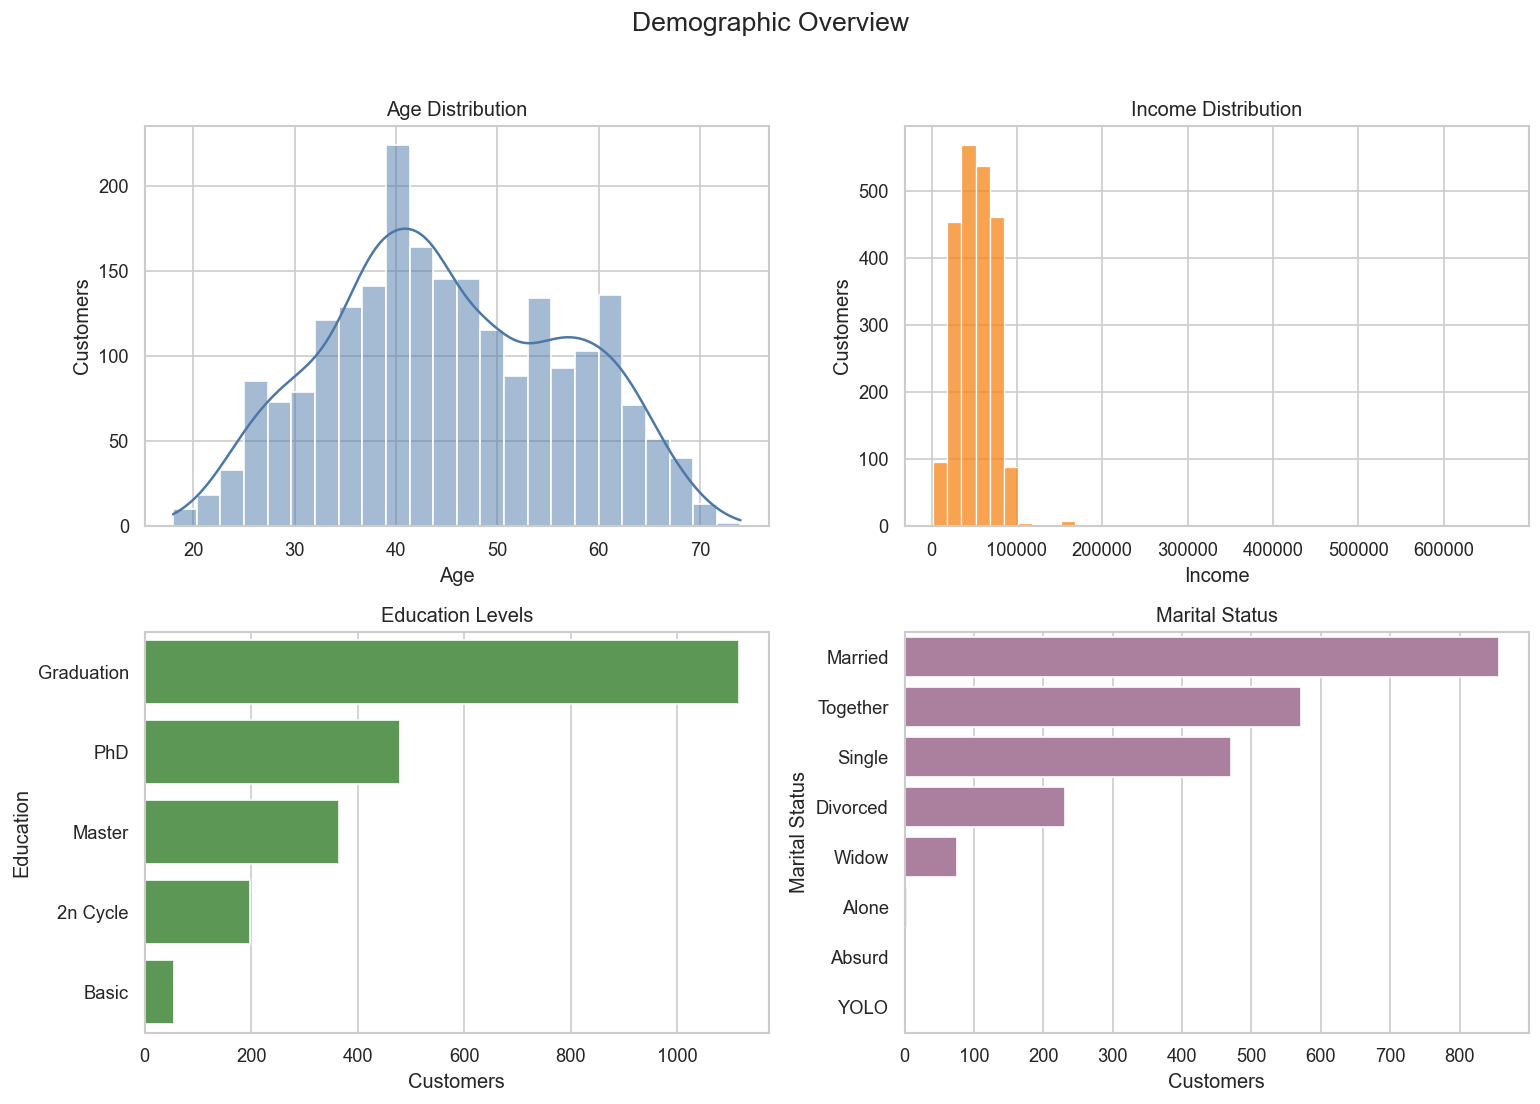

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(df["age"], bins=24, kde=True, ax=axes[0, 0], color="#4C78A8")
axes[0, 0].set_title("Age Distribution")
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Customers")

sns.histplot(df["income"], bins=40, kde=False, ax=axes[0, 1], color="#F58518")
axes[0, 1].set_title("Income Distribution")
axes[0, 1].set_xlabel("Income")
axes[0, 1].set_ylabel("Customers")

education_order = df["education"].value_counts().index
sns.countplot(data=df, y="education", order=education_order, ax=axes[1, 0], color="#54A24B")
axes[1, 0].set_title("Education Levels")
axes[1, 0].set_xlabel("Customers")
axes[1, 0].set_ylabel("Education")

marital_order = df["marital_status"].value_counts().index
sns.countplot(data=df, y="marital_status", order=marital_order, ax=axes[1, 1], color="#B279A2")
axes[1, 1].set_title("Marital Status")
axes[1, 1].set_xlabel("Customers")
axes[1, 1].set_ylabel("Marital Status")

fig.suptitle("Demographic Overview", fontsize=16, y=1.02)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "eda_demographics.png", bbox_inches="tight")
plt.show()

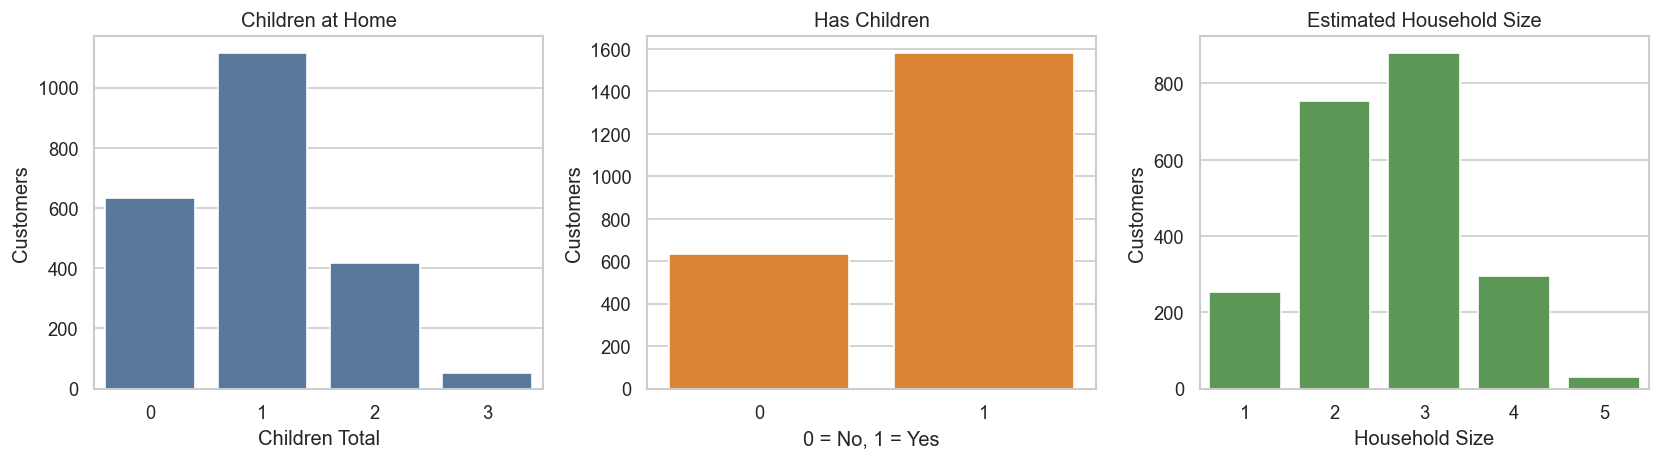

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.countplot(data=df, x="children_total", ax=axes[0], color="#4C78A8")
axes[0].set_title("Children at Home")
axes[0].set_xlabel("Children Total")
axes[0].set_ylabel("Customers")

sns.countplot(data=df, x="has_children", ax=axes[1], color="#F58518")
axes[1].set_title("Has Children")
axes[1].set_xlabel("0 = No, 1 = Yes")
axes[1].set_ylabel("Customers")

sns.countplot(data=df, x="household_size", ax=axes[2], color="#54A24B")
axes[2].set_title("Estimated Household Size")
axes[2].set_xlabel("Household Size")
axes[2].set_ylabel("Customers")

fig.tight_layout()
plt.show()

**Demographic interpretation:** The dataset is concentrated in middle-aged adults, with ages from 18 to 74 after cleaning. Graduation is the most common education level, and most customers have at least one child at home. Income is right-skewed and includes a very large maximum, so later analysis should handle income carefully.

## Spending Behavior Analysis

Spending variables summarize total product spending and the mix of product categories. These are likely to be useful for later clustering because they describe customer behavior directly.

In [7]:
product_spending_cols = [
    "mnt_wines",
    "mnt_fruits",
    "mnt_meat_products",
    "mnt_fish_products",
    "mnt_sweet_products",
    "mnt_gold_prods",
]
spending_share_cols = [
    "wine_share",
    "fruits_share",
    "meat_share",
    "fish_share",
    "sweets_share",
    "gold_share",
]
spending_features = [
    "total_spending",
    "luxury_spending_ratio",
    "spending_per_tenure_year",
] + spending_share_cols

display(df[spending_features].describe().T)

product_totals = df[product_spending_cols].sum().sort_values(ascending=False)
display(product_totals.to_frame("total_spending"))

,count,mean,std,min,25%,50%,75%,max
total_spending,2213.0,607.021690,602.488663,5.000000,69.000000,397.000000,1048.000000,2525.000000
luxury_spending_ratio,2213.0,0.578929,0.194040,0.001156,0.428714,0.571429,0.737844,0.972477
spending_per_tenure_year,2213.0,2222.856039,15492.132710,4.131787,113.958000,453.979617,1107.532258,359406.000000
wine_share,2213.0,0.458868,0.228649,0.000000,0.289803,0.458115,0.641164,0.963303
fruits_share,2213.0,0.049542,0.055889,0.000000,0.008989,0.029830,0.070175,0.445545
meat_share,2213.0,0.249118,0.125752,0.000000,0.156250,0.233333,0.328221,0.997110
fish_share,2213.0,0.071638,0.078028,0.000000,0.012575,0.048193,0.104925,0.590909
sweets_share,2213.0,0.050774,0.060945,0.000000,0.008631,0.033333,0.070707,0.945848
gold_share,2213.0,0.120060,0.108818,0.000000,0.038038,0.085714,0.169811,0.894150


,total_spending
mnt_wines,675305
mnt_meat_products,369488
mnt_gold_prods,97176
mnt_fish_products,83287
mnt_sweet_products,59828
mnt_fruits,58255


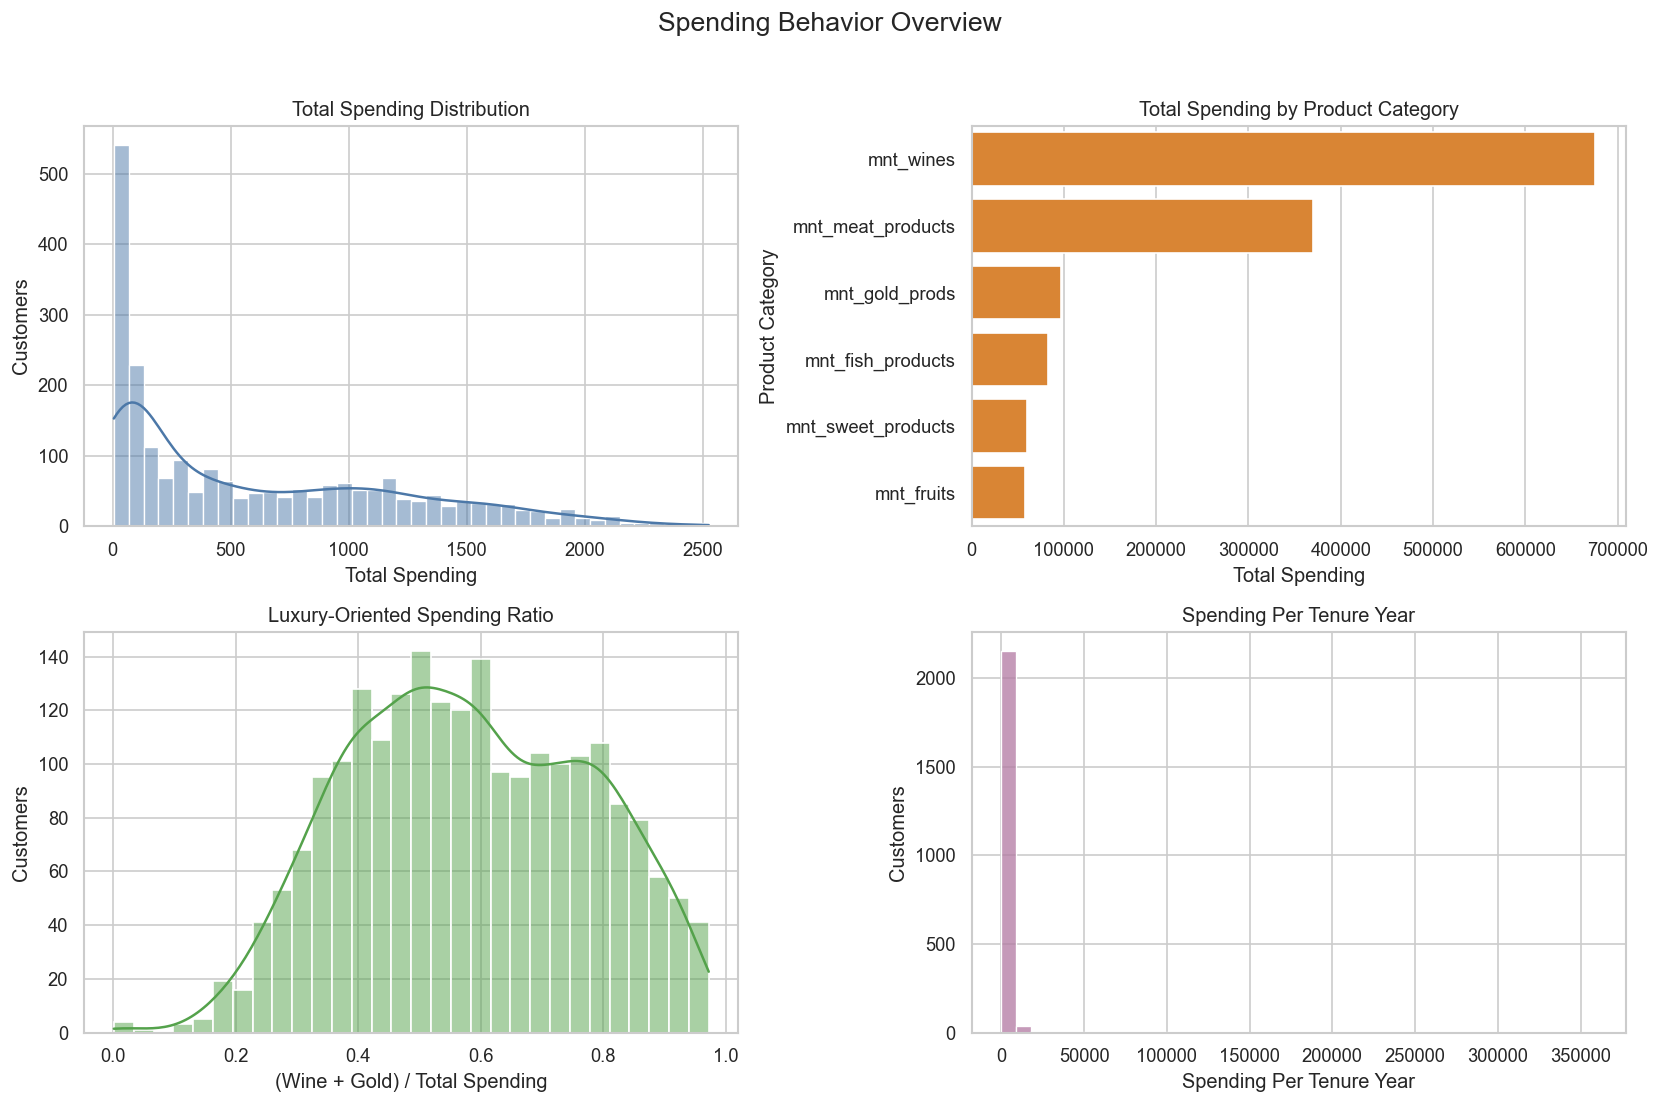

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.histplot(df["total_spending"], bins=40, kde=True, ax=axes[0, 0], color="#4C78A8")
axes[0, 0].set_title("Total Spending Distribution")
axes[0, 0].set_xlabel("Total Spending")
axes[0, 0].set_ylabel("Customers")

sns.barplot(x=product_totals.values, y=product_totals.index, ax=axes[0, 1], color="#F58518")
axes[0, 1].set_title("Total Spending by Product Category")
axes[0, 1].set_xlabel("Total Spending")
axes[0, 1].set_ylabel("Product Category")

sns.histplot(df["luxury_spending_ratio"], bins=30, kde=True, ax=axes[1, 0], color="#54A24B")
axes[1, 0].set_title("Luxury-Oriented Spending Ratio")
axes[1, 0].set_xlabel("(Wine + Gold) / Total Spending")
axes[1, 0].set_ylabel("Customers")

sns.histplot(df["spending_per_tenure_year"], bins=40, kde=False, ax=axes[1, 1], color="#B279A2")
axes[1, 1].set_title("Spending Per Tenure Year")
axes[1, 1].set_xlabel("Spending Per Tenure Year")
axes[1, 1].set_ylabel("Customers")

fig.suptitle("Spending Behavior Overview", fontsize=16, y=1.02)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "eda_spending_behavior.png", bbox_inches="tight")
plt.show()

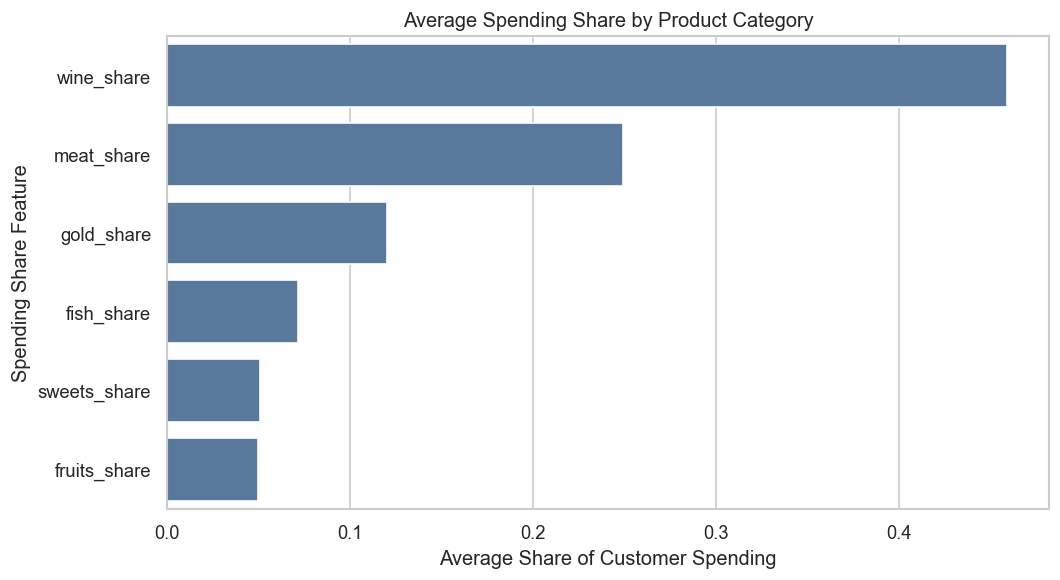

,average_share
wine_share,0.458868
meat_share,0.249118
gold_share,0.120060
fish_share,0.071638
sweets_share,0.050774
fruits_share,0.049542


In [9]:
share_means = df[spending_share_cols].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=share_means.values, y=share_means.index, ax=ax, color="#4C78A8")
ax.set_title("Average Spending Share by Product Category")
ax.set_xlabel("Average Share of Customer Spending")
ax.set_ylabel("Spending Share Feature")
fig.tight_layout()
plt.show()

display(share_means.to_frame("average_share"))

**Spending interpretation:** Wine and meat account for the largest portions of spending in this dataset. Total spending is highly spread out, with many low-spend customers and a smaller group of high-spend customers. Spending mix, total spending, and annualized spending all look useful for later segmentation.

## Purchase Behavior Analysis

Purchase behavior describes how customers buy: web, catalog, store, and deal-oriented purchasing. These variables may help distinguish channel preferences and purchasing intensity.

In [10]:
purchase_features = [
    "total_purchases",
    "total_store_web_catalog_purchases",
    "web_purchase_share",
    "store_purchase_share",
    "catalog_purchase_share",
    "deal_purchase_share",
    "average_spend_per_purchase",
]
purchase_count_cols = [
    "num_web_purchases",
    "num_catalog_purchases",
    "num_store_purchases",
    "num_deals_purchases",
]

display(df[purchase_features].describe().T)
display(df[purchase_count_cols].sum().sort_values(ascending=False).to_frame("total_count"))

,count,mean,std,min,25%,50%,75%,max
total_purchases,2213.0,14.889742,7.670341,0.0,8.000000,15.000000,21.000000,44.000000
total_store_web_catalog_purchases,2213.0,12.564392,7.204770,0.0,6.000000,12.000000,18.000000,32.000000
web_purchase_share,2213.0,0.328887,0.122083,0.0,0.250000,0.333333,0.400000,1.000000
store_purchase_share,2213.0,0.503673,0.151081,0.0,0.400000,0.500000,0.600000,1.000000
catalog_purchase_share,2213.0,0.164729,0.140594,0.0,0.000000,0.150000,0.250000,1.000000
deal_purchase_share,2213.0,0.180277,0.111247,0.0,0.076923,0.166667,0.250000,1.000000
average_spend_per_purchase,2213.0,37.436296,30.087924,0.0,13.000000,29.833333,49.166667,187.666667


,total_count
num_store_purchases,12847
num_web_purchases,9046
num_catalog_purchases,5912
num_deals_purchases,5146


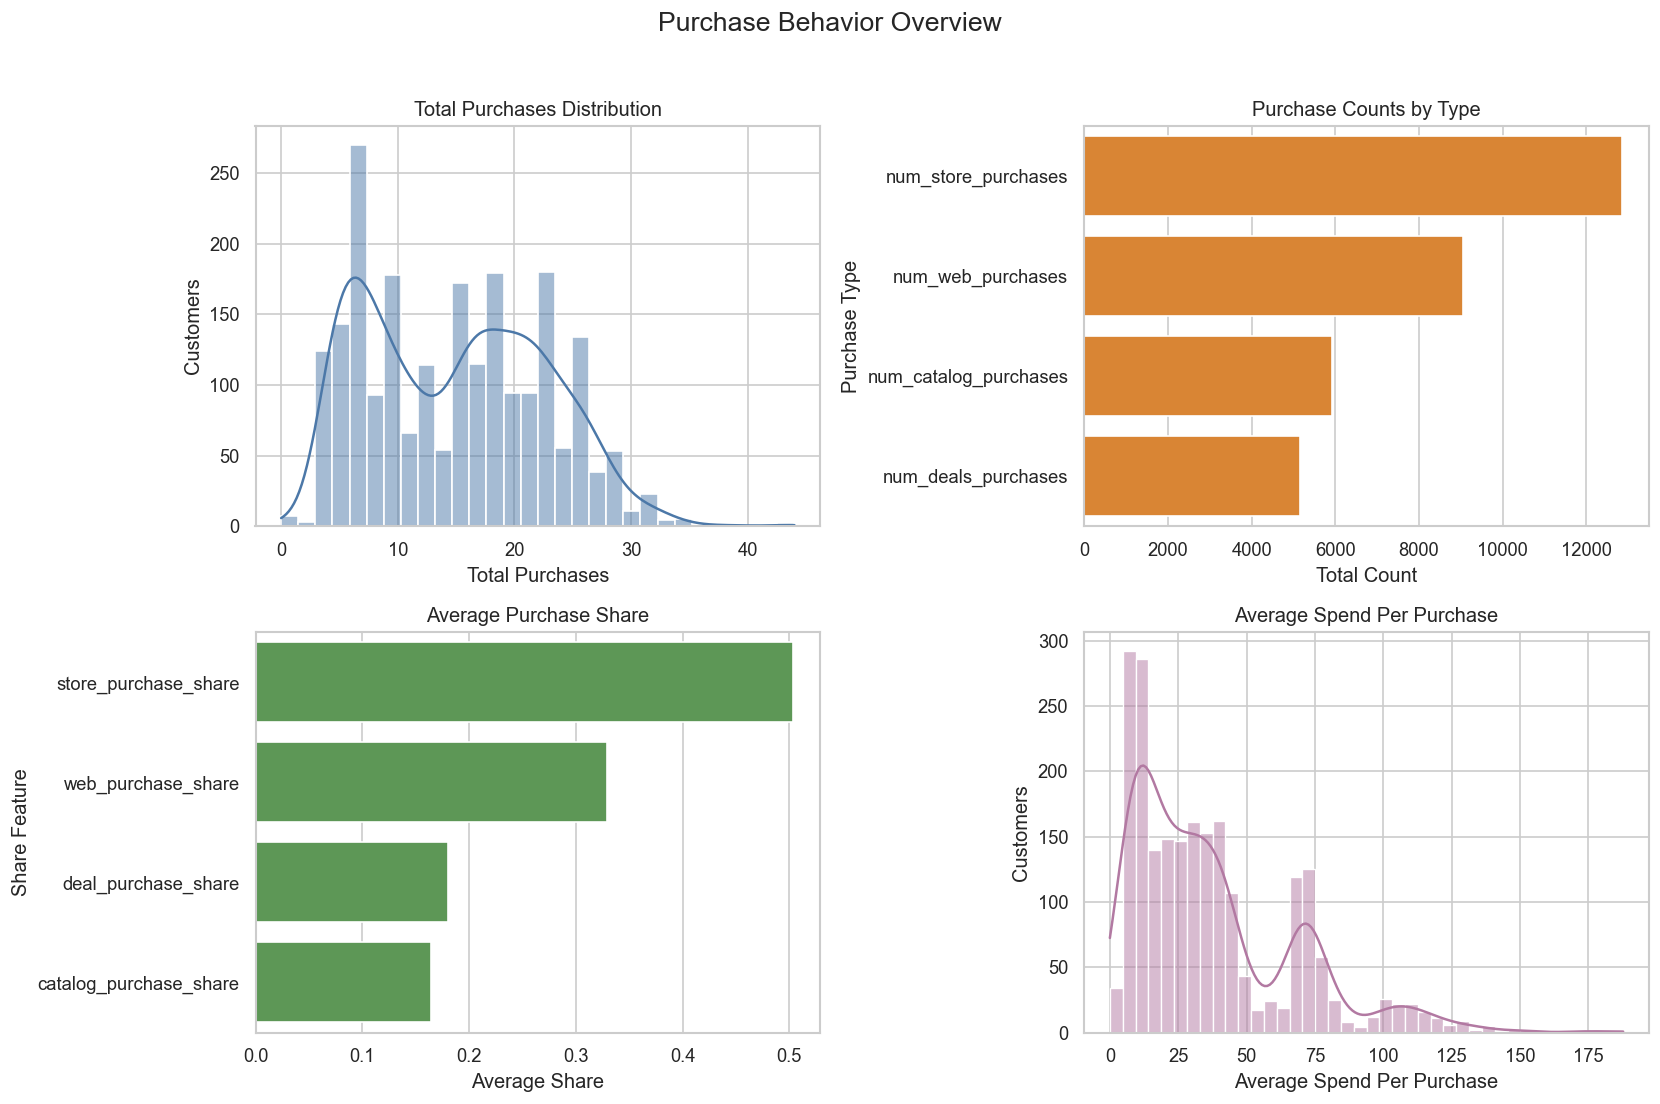

In [11]:
purchase_totals = df[purchase_count_cols].sum().sort_values(ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.histplot(df["total_purchases"], bins=30, kde=True, ax=axes[0, 0], color="#4C78A8")
axes[0, 0].set_title("Total Purchases Distribution")
axes[0, 0].set_xlabel("Total Purchases")
axes[0, 0].set_ylabel("Customers")

sns.barplot(x=purchase_totals.values, y=purchase_totals.index, ax=axes[0, 1], color="#F58518")
axes[0, 1].set_title("Purchase Counts by Type")
axes[0, 1].set_xlabel("Total Count")
axes[0, 1].set_ylabel("Purchase Type")

channel_share_means = df[["web_purchase_share", "store_purchase_share", "catalog_purchase_share", "deal_purchase_share"]].mean().sort_values(ascending=False)
sns.barplot(x=channel_share_means.values, y=channel_share_means.index, ax=axes[1, 0], color="#54A24B")
axes[1, 0].set_title("Average Purchase Share")
axes[1, 0].set_xlabel("Average Share")
axes[1, 0].set_ylabel("Share Feature")

sns.histplot(df["average_spend_per_purchase"], bins=40, kde=True, ax=axes[1, 1], color="#B279A2")
axes[1, 1].set_title("Average Spend Per Purchase")
axes[1, 1].set_xlabel("Average Spend Per Purchase")
axes[1, 1].set_ylabel("Customers")

fig.suptitle("Purchase Behavior Overview", fontsize=16, y=1.02)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "eda_purchase_behavior.png", bbox_inches="tight")
plt.show()

**Purchase interpretation:** Store purchases are the largest channel by total count, followed by web and catalog. Purchase intensity and channel preference should be useful for clustering because they describe how customers interact with the business.

## Campaign Behavior Analysis

This section reviews historical campaign acceptance and the original `response` field. The response column is kept unchanged for now; no final supervised target is created in this notebook.

In [12]:
campaign_cols = ["accepted_cmp1", "accepted_cmp2", "accepted_cmp3", "accepted_cmp4", "accepted_cmp5"]
campaign_features = campaign_cols + ["total_campaign_acceptances", "any_campaign_acceptance", "response"]

display(df[campaign_features].describe().T)
display(df[campaign_cols + ["response"]].sum().to_frame("accepted_or_response_count"))

response_rate = df["response"].mean()
prior_campaign_response = df.groupby("any_campaign_acceptance")["response"].agg(["mean", "count"])
prior_campaign_response["response_rate_percent"] = prior_campaign_response["mean"] * 100

print(f"Overall response rate: {response_rate:.2%}")
display(prior_campaign_response)

,count,mean,std,min,25%,50%,75%,max
accepted_cmp1,2213.0,0.064166,0.245104,0.0,0.0,0.0,0.0,1.0
accepted_cmp2,2213.0,0.013556,0.115666,0.0,0.0,0.0,0.0,1.0
accepted_cmp3,2213.0,0.073656,0.261269,0.0,0.0,0.0,0.0,1.0
accepted_cmp4,2213.0,0.074108,0.262005,0.0,0.0,0.0,0.0,1.0
accepted_cmp5,2213.0,0.072752,0.259788,0.0,0.0,0.0,0.0,1.0
total_campaign_acceptances,2213.0,0.298238,0.679446,0.0,0.0,0.0,0.0,4.0
any_campaign_acceptance,2213.0,0.206959,0.405217,0.0,0.0,0.0,0.0,1.0
response,2213.0,0.150474,0.357617,0.0,0.0,0.0,0.0,1.0


,accepted_or_response_count
accepted_cmp1,142
accepted_cmp2,30
accepted_cmp3,163
accepted_cmp4,164
accepted_cmp5,161
response,333


Overall response rate: 15.05%


,mean,count,response_rate_percent
any_campaign_acceptance,,,
0,0.083191,1755,8.319088
1,0.408297,458,40.829694


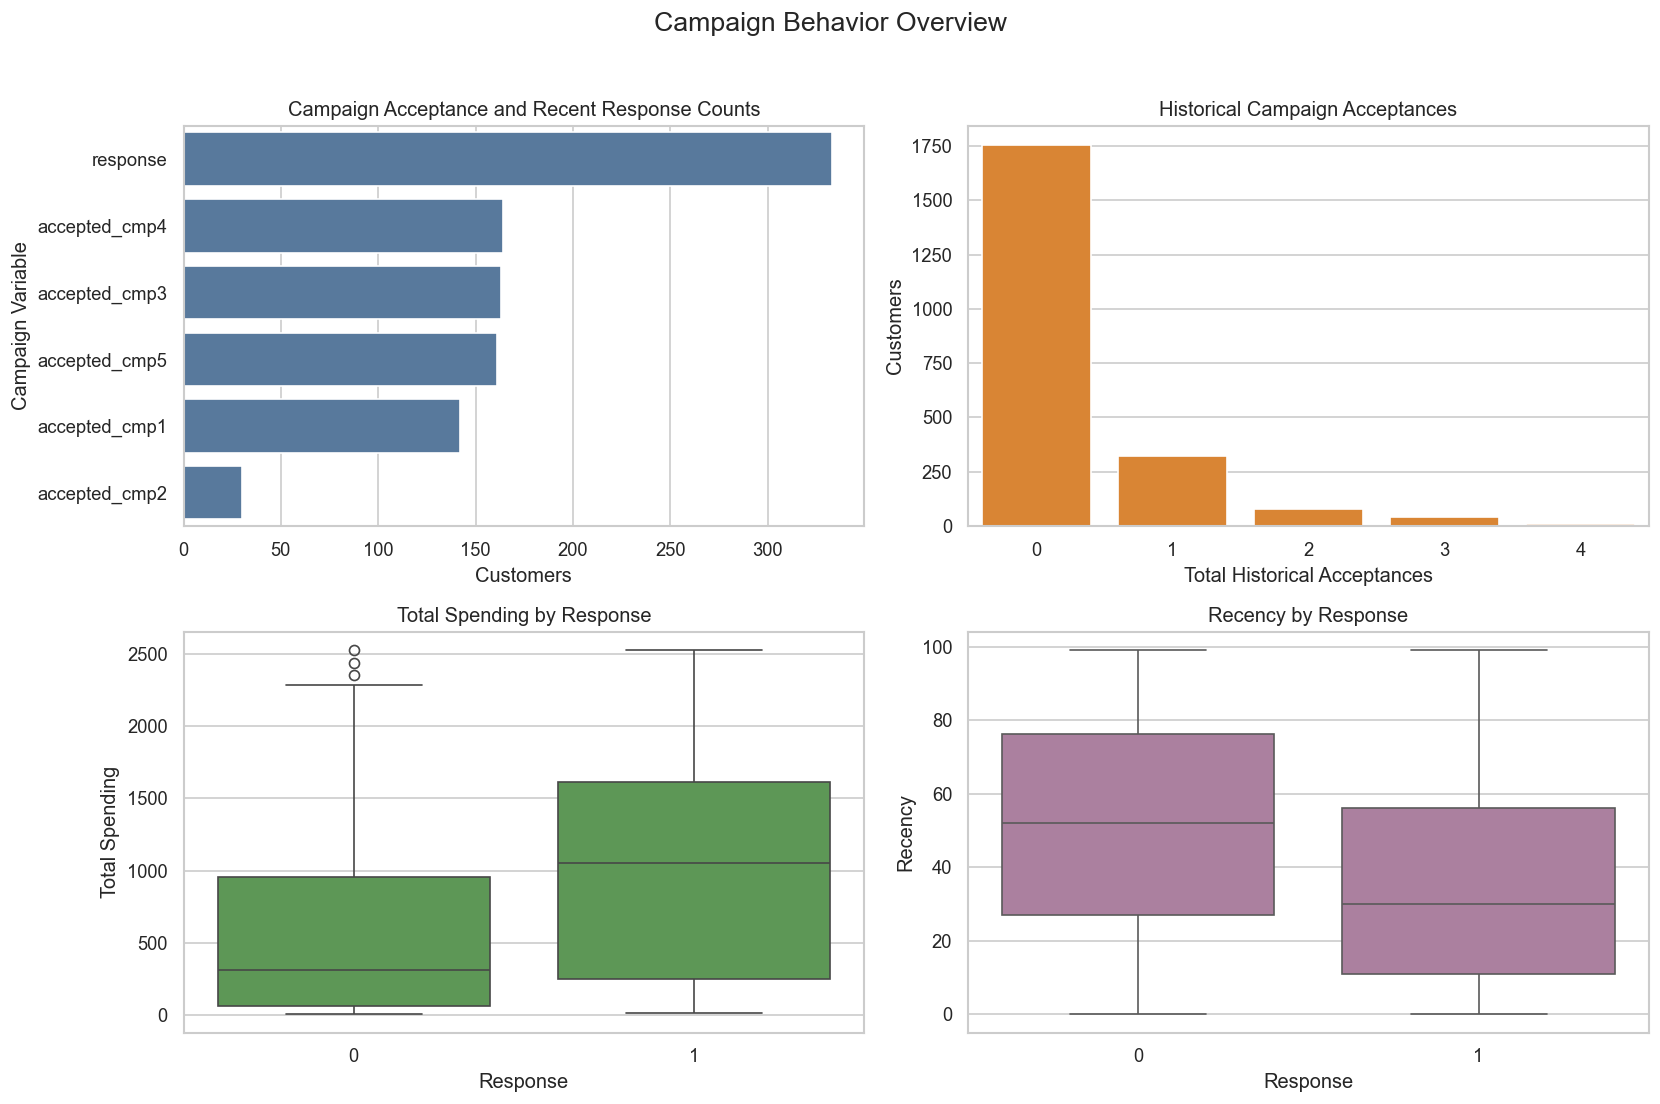

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

campaign_counts = df[campaign_cols + ["response"]].sum().sort_values(ascending=False)
sns.barplot(x=campaign_counts.values, y=campaign_counts.index, ax=axes[0, 0], color="#4C78A8")
axes[0, 0].set_title("Campaign Acceptance and Recent Response Counts")
axes[0, 0].set_xlabel("Customers")
axes[0, 0].set_ylabel("Campaign Variable")

sns.countplot(data=df, x="total_campaign_acceptances", ax=axes[0, 1], color="#F58518")
axes[0, 1].set_title("Historical Campaign Acceptances")
axes[0, 1].set_xlabel("Total Historical Acceptances")
axes[0, 1].set_ylabel("Customers")

sns.boxplot(data=df, x="response", y="total_spending", ax=axes[1, 0], color="#54A24B")
axes[1, 0].set_title("Total Spending by Response")
axes[1, 0].set_xlabel("Response")
axes[1, 0].set_ylabel("Total Spending")

sns.boxplot(data=df, x="response", y="recency", ax=axes[1, 1], color="#B279A2")
axes[1, 1].set_title("Recency by Response")
axes[1, 1].set_xlabel("Response")
axes[1, 1].set_ylabel("Recency")

fig.suptitle("Campaign Behavior Overview", fontsize=16, y=1.02)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "eda_campaign_behavior.png", bbox_inches="tight")
plt.show()

,income,total_spending,recency,total_purchases,total_campaign_acceptances,age
response,,,,,,
0,50824.33,539.95,51.44,14.39,0.18,45.19
1,60209.68,985.66,35.26,17.69,0.99,44.50


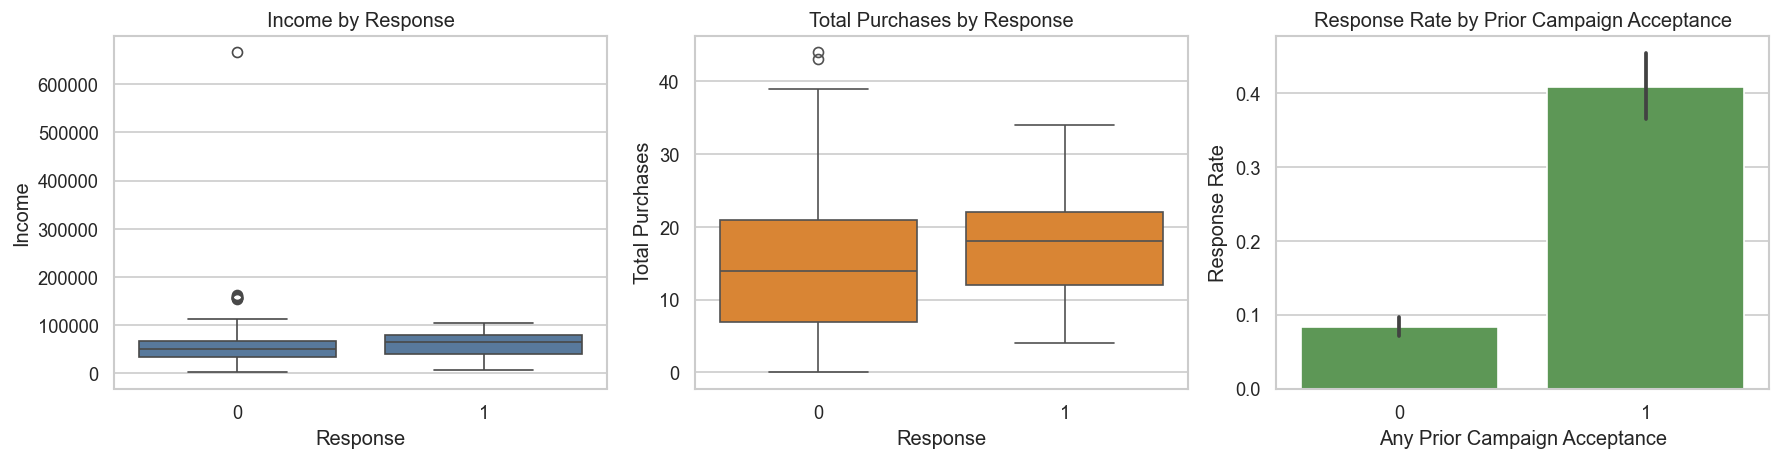

In [14]:
response_comparison = df.groupby("response")[
    ["income", "total_spending", "recency", "total_purchases", "total_campaign_acceptances", "age"]
].mean().round(2)
display(response_comparison)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(data=df, x="response", y="income", ax=axes[0], color="#4C78A8")
axes[0].set_title("Income by Response")
axes[0].set_xlabel("Response")
axes[0].set_ylabel("Income")

sns.boxplot(data=df, x="response", y="total_purchases", ax=axes[1], color="#F58518")
axes[1].set_title("Total Purchases by Response")
axes[1].set_xlabel("Response")
axes[1].set_ylabel("Total Purchases")

sns.barplot(data=df, x="any_campaign_acceptance", y="response", ax=axes[2], color="#54A24B")
axes[2].set_title("Response Rate by Prior Campaign Acceptance")
axes[2].set_xlabel("Any Prior Campaign Acceptance")
axes[2].set_ylabel("Response Rate")

fig.tight_layout()
plt.show()

**Campaign interpretation:** Only about 15% of customers responded to the recent campaign. Customers with at least one prior campaign acceptance show a noticeably higher response rate in this dataset. Response also appears associated with total spending, average spend per purchase, recency, and campaign history, which should be considered later during supervised modeling.

## Correlation Analysis

The heatmap below uses a focused set of numerical variables to keep the visualization readable. It is meant to identify relationships worth investigating, not to prove causation.

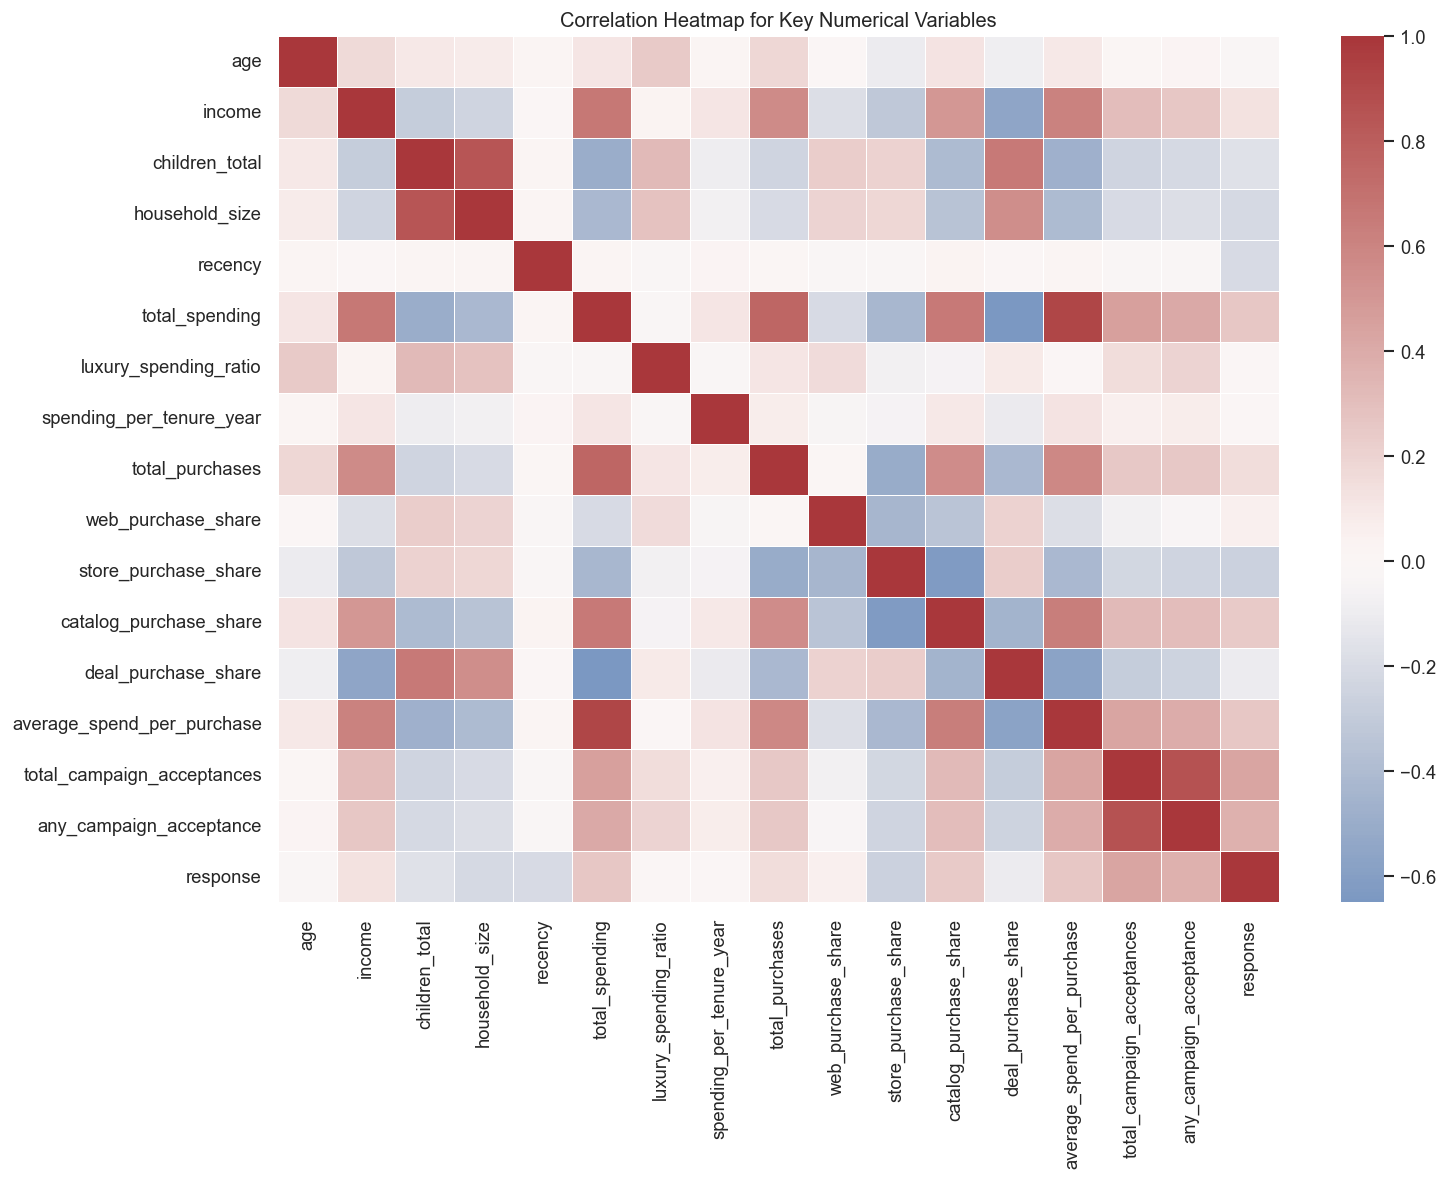

Variables most correlated with response by absolute correlation:


,correlation_with_response
total_campaign_acceptances,0.427345
any_campaign_acceptance,0.368379
total_spending,0.264556
average_spend_per_purchase,0.262617
store_purchase_share,-0.262447
catalog_purchase_share,0.243385
household_size,-0.218449
recency,-0.199899
children_total,-0.167943
total_purchases,0.153885


Variables most correlated with total spending by absolute correlation:


,correlation_with_total_spending
average_spend_per_purchase,0.918099
total_purchases,0.756900
income,0.667516
catalog_purchase_share,0.662418
deal_purchase_share,-0.650610
children_total,-0.499866
total_campaign_acceptances,0.456531
store_purchase_share,-0.436758
household_size,-0.424583
any_campaign_acceptance,0.411368


In [15]:
correlation_cols = [
    "age",
    "income",
    "children_total",
    "household_size",
    "recency",
    "total_spending",
    "luxury_spending_ratio",
    "spending_per_tenure_year",
    "total_purchases",
    "web_purchase_share",
    "store_purchase_share",
    "catalog_purchase_share",
    "deal_purchase_share",
    "average_spend_per_purchase",
    "total_campaign_acceptances",
    "any_campaign_acceptance",
    "response",
]

corr = df[correlation_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr, cmap="vlag", center=0, linewidths=0.4, square=False, ax=ax)
ax.set_title("Correlation Heatmap for Key Numerical Variables")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "eda_correlation_heatmap.png", bbox_inches="tight")
plt.show()

print("Variables most correlated with response by absolute correlation:")
display(corr["response"].drop("response").sort_values(key=lambda values: values.abs(), ascending=False).head(10).to_frame("correlation_with_response"))

print("Variables most correlated with total spending by absolute correlation:")
display(corr["total_spending"].drop("total_spending").sort_values(key=lambda values: values.abs(), ascending=False).head(10).to_frame("correlation_with_total_spending"))

**Correlation interpretation:** Spending, purchase, household, and campaign-history variables show meaningful relationships. For later clustering, variables like total spending, spending mix, channel shares, total purchases, children/household variables, and income may be useful. For later prediction, campaign history, recency, spending, purchase intensity, and household variables may be relevant.

## Outlier Review

This section reviews possible outliers in income, age, total spending, and total purchases. No outliers are removed here; they are only flagged for later consideration.

In [16]:
outlier_review_cols = ["income", "age", "total_spending", "total_purchases"]

outlier_summary = []
for column in outlier_review_cols:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
    outlier_summary.append({
        "column": column,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "possible_outlier_count": int(outlier_count),
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
display(outlier_summary_df)

print("Top income values")
display(df.nlargest(5, "income")[["id", "age", "income", "total_spending", "total_purchases", "response"]])

print("Top total spending values")
display(df.nlargest(5, "total_spending")[["id", "age", "income", "total_spending", "total_purchases", "response"]])

print("Top total purchase values")
display(df.nlargest(5, "total_purchases")[["id", "age", "income", "total_spending", "total_purchases", "response"]])

,column,q1,q3,iqr,lower_bound,upper_bound,possible_outlier_count
0,income,35246.0,68487.0,33241.0,-14615.5,118348.5,8
1,age,37.0,55.0,18.0,10.0,82.0,0
2,total_spending,69.0,1048.0,979.0,-1399.5,2516.5,3
3,total_purchases,8.0,21.0,13.0,-11.5,40.5,2


Top income values


,id,age,income,total_spending,total_purchases,response
2206,9432,37,666666.0,62,11,0
601,1503,38,162397.0,107,1,0
671,1501,32,160803.0,1717,44,0
1284,5336,43,157733.0,59,2,0
153,8475,41,157243.0,1608,37,0


Top total spending values


,id,age,income,total_spending,total_purchases,response
1163,5735,23,90638.0,2525,18,0
1552,5350,23,90638.0,2525,18,1
1472,1763,26,87679.0,2524,29,1
971,4580,45,75759.0,2486,26,1
1036,4475,65,69098.0,2440,25,0


Top total purchase values


,id,age,income,total_spending,total_purchases,response
671,1501,32,160803.0,1717,44,0
20,5376,35,2447.0,1730,43,0
416,238,47,67309.0,1082,39,0
153,8475,41,157243.0,1608,37,0
396,7030,59,66465.0,1485,35,0


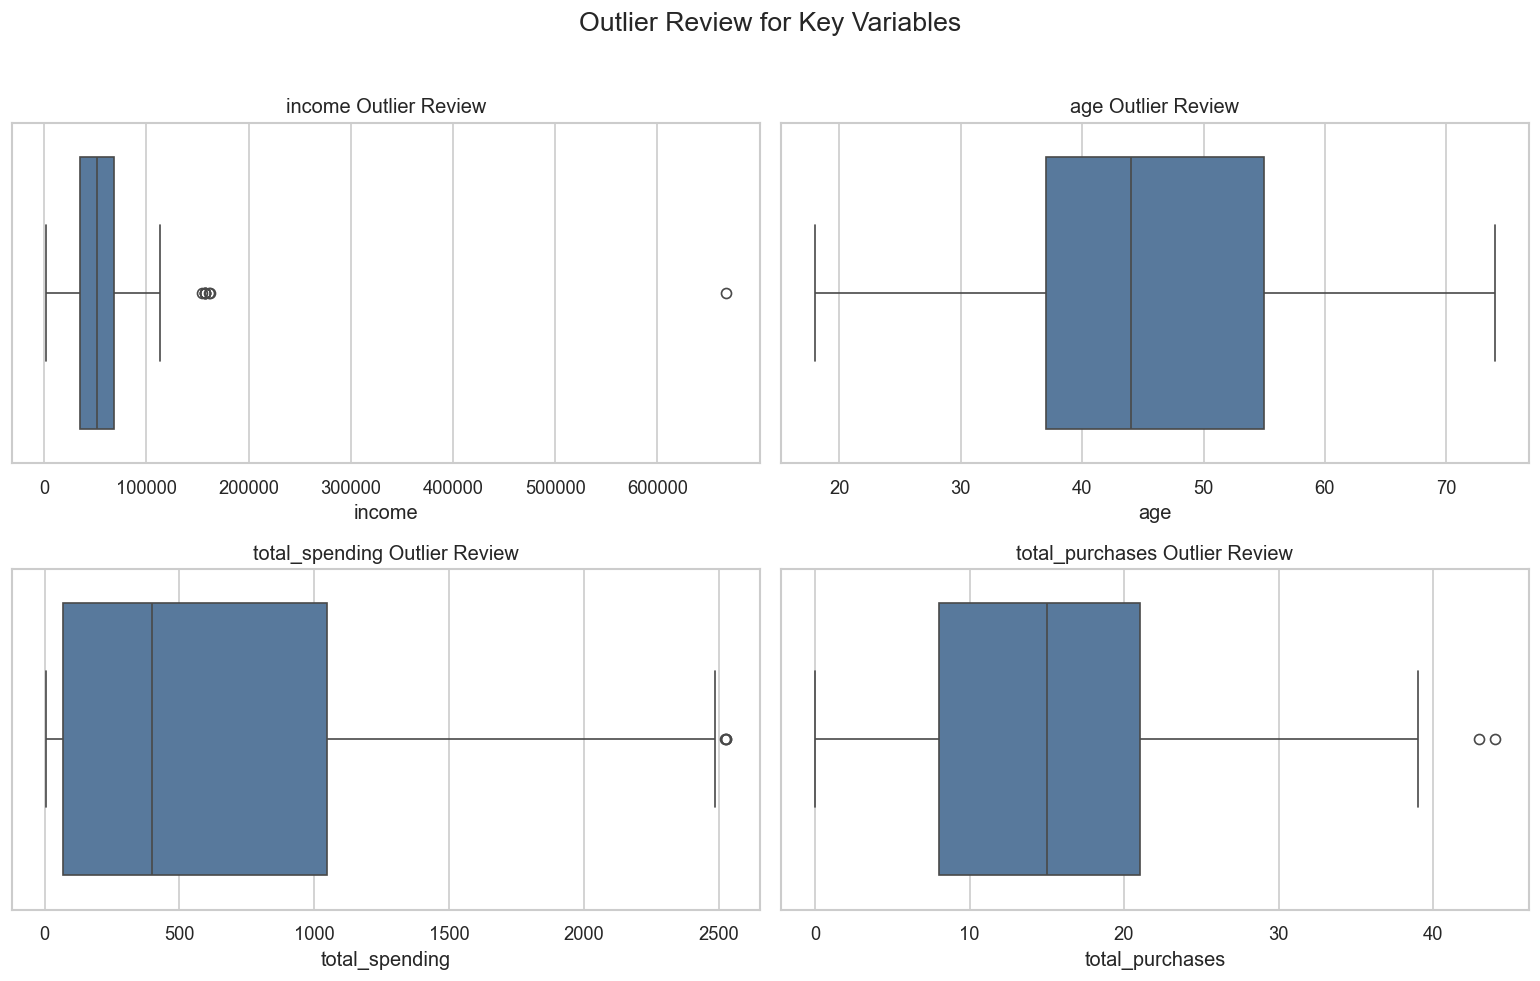

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, column in zip(axes.ravel(), outlier_review_cols):
    sns.boxplot(data=df, x=column, ax=ax, color="#4C78A8")
    ax.set_title(f"{column} Outlier Review")
    ax.set_xlabel(column)

fig.suptitle("Outlier Review for Key Variables", fontsize=16, y=1.02)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "eda_outlier_review.png", bbox_inches="tight")
plt.show()

**Outlier interpretation:** Age no longer contains obvious impossible values after cleaning. Income has a very large maximum compared with the rest of the distribution, and a small number of high total-spending and high-purchase customers also stand out. These should be reviewed later before clustering or modeling, but they are not removed in this EDA step.

## Initial Insights

1. The dataset has 2,213 customers and 53 columns after feature engineering, with no missing or infinite values.
2. The customer age range is 18 to 74, and no age outliers are flagged by the IQR rule after the earlier cleaning step.
3. Income is strongly right-skewed and includes a very large maximum (`666666`), so income should be treated carefully in later clustering and modeling.
4. Wine and meat are the largest spending categories by total amount and average spending share.
5. Store purchases are the most common purchase channel by total count, followed by web and catalog purchases.
6. The recent campaign response rate is about 15%, meaning supervised modeling will likely involve an imbalanced outcome if `response` is used later.
7. Customers with prior campaign acceptance show a higher recent response rate in this dataset, making campaign-history variables potentially useful for prediction.
8. Variables that look useful for clustering include total spending, spending shares, income, children/household variables, total purchases, and purchase-channel shares. Variables that may help supervised modeling include campaign history, recency, total spending, average spend per purchase, total purchases, household size, and children indicators.

**Risks and cautions:** Spending, income, and purchase variables are skewed; income has a notable extreme value; and campaign response is imbalanced. These issues should be handled thoughtfully in later preprocessing and modeling steps.

In [18]:
saved_figures = sorted(path.name for path in FIGURE_DIR.glob("eda_*.png"))
print("Saved EDA figures:")
for figure in saved_figures:
    print(f"- {figure}")

assert missing_total == 0
assert infinite_total == 0

Saved EDA figures:
- eda_campaign_behavior.png
- eda_correlation_heatmap.png
- eda_demographics.png
- eda_outlier_review.png
- eda_purchase_behavior.png
- eda_spending_behavior.png
